# TAE-IA · Módulo 6 · L11 — Vision App

A working two-model pipeline behind a web interface. **You are given this notebook** — read it,
run it, then break it on purpose in section 7.

| | |
|---|---|
| **Models** | YOLOv8n 6 MB · BLIP-large 1.9 GB · SD 1.5 fp16 2.5 GB — 4.4 GB download, ~3.2 GB VRAM |
| **Inputs** | five images you choose, in `TAE_IA_M6/inputs/` |
| **Outputs** | `TAE_IA_M6/L11_output/` on Drive |

In L12 you build your own app on top of this one.

## 1 — Setup

Colab does not ship `ultralytics`, `diffusers` or `gradio`, so install them first — about a
minute. Then: weights go on the runtime disk (fast, roomy, wiped between sessions), while your
images and outputs go on Drive, where they survive.

In [ ]:
!pip install -q ultralytics diffusers transformers accelerate gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.3 MB/s eta 0:00:00


In [ ]:
import os, time, random
import numpy as np
import torch
from PIL import Image, ImageDraw

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
OUTPUT_DIR = f'{DRIVE_ROOT}/L11_output'
INPUT_DIR  = f'{DRIVE_ROOT}/inputs'       # shared by every lab in the module
for d in (OUTPUT_DIR, INPUT_DIR):
    os.makedirs(d, exist_ok=True)

# Drive is a network mount with no symlink support, so HuggingFace's cache
# raises OSError 95 there. The runtime disk has neither problem.
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
os.environ['HF_HOME']         = MODEL_CACHE
os.environ['TORCH_HOME']      = MODEL_CACHE
os.environ['YOLO_CONFIG_DIR'] = MODEL_CACHE

if not torch.cuda.is_available():
    raise SystemExit('No GPU. Runtime > Change runtime type > T4 GPU')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def vram(tag=''):
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM {used:5.2f} / {total:.1f} GB   {tag}')

print(torch.cuda.get_device_name(0)); vram('empty')

Mounted at /content/drive
Tesla T4
  VRAM  0.00 / 15.6 GB   empty


## 2 — Your five images

Put five images in `TAE_IA_M6/inputs/` before running the rest. `upload_inputs()` opens a file
picker and writes straight to Drive, so they stay there for every later session.

In [ ]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')

def upload_inputs():
    from google.colab import files
    for name, data in files.upload().items():
        with open(os.path.join(INPUT_DIR, name), 'wb') as f:
            f.write(data)
        print('saved', name)

def load_inputs(n=7):
    names = [f for f in sorted(os.listdir(INPUT_DIR))
             if f.lower().endswith(IMG_EXTS)][:n]
    if not names:
        raise SystemExit(f'No images in {INPUT_DIR}. Run upload_inputs() first.')
    return {f: Image.open(os.path.join(INPUT_DIR, f)).convert('RGB') for f in names}

# upload_inputs()          # <- uncomment and run once if the folder is empty
print(f'{len(load_inputs())} images ready in {INPUT_DIR}')

7 images ready in /content/drive/MyDrive/TAE_IA_M6/inputs


## 3 — Load the models

Three models, one cell. Watch the VRAM line grow after each — that number is the answer to
"will my project fit on a T4".

In [ ]:
from huggingface_hub import snapshot_download
from ultralytics import YOLO
from transformers import BlipProcessor, BlipForConditionalGeneration
from diffusers import StableDiffusionImg2ImgPipeline, DPMSolverMultistepScheduler

def fetch(repo, name, patterns):
    """Download only the files we need - most repos ship the same weights 3x."""
    target = os.path.join(MODEL_CACHE, name)
    snapshot_download(repo, local_dir=target, allow_patterns=patterns)
    return target

yolo = YOLO('yolov8n.pt')                                    # 6 MB, ~12 ms
print(f'YOLO: {len(yolo.names)} COCO classes')

blip_dir   = fetch('Salesforce/blip-image-captioning-large', 'blip-large',
                   ['*.json', '*.txt', '*.safetensors'])     # 1.9 GB, ~0.5 s
blip_proc  = BlipProcessor.from_pretrained(blip_dir)
blip_model = BlipForConditionalGeneration.from_pretrained(
    blip_dir, torch_dtype=torch.float16).to('cuda').eval()
vram('after BLIP')

sd_dir  = fetch('stable-diffusion-v1-5/stable-diffusion-v1-5', 'sd15',
                ['*.json', '*.txt', '*.fp16.safetensors'])   # 2.5 GB, ~3.6 s
pipe_sd = StableDiffusionImg2ImgPipeline.from_pretrained(
    sd_dir, torch_dtype=torch.float16, variant='fp16').to('cuda')
# DPMSolver: same quality in ~20 steps instead of ~50 (this is the L06 lesson paying off)
pipe_sd.scheduler = DPMSolverMultistepScheduler.from_config(pipe_sd.scheduler.config)
pipe_sd.set_progress_bar_config(disable=True)
vram('all three resident')

YOLO: 80 COCO classes


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

  VRAM  3.72 / 15.6 GB   after BLIP


...

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  VRAM  3.70 / 15.6 GB   all three resident


## 4 — The input contract, and one wrapper per model

`coerce_image` is the important one. Every stage boundary is a place where the type, the size or
the colour mode can be wrong, and a pipeline that assumes instead of checking fails silently —
which is worse than crashing, because you get a confident wrong answer.

In [ ]:
MAX_SIDE, MIN_SIDE = 1024, 32

def coerce_image(x):
    """Anything a user can hand us -> PIL RGB, or ValueError with a readable message."""
    if x is None:
        raise ValueError('No image received. Please upload one.')
    if isinstance(x, np.ndarray):            # Gradio hands you numpy, not PIL
        x = Image.fromarray(x.astype(np.uint8))
    if not isinstance(x, Image.Image):
        raise ValueError('Unsupported input. Please upload an image file.')
    x = x.convert('RGB')                     # handles L, RGBA, P, CMYK
    w, h = x.size
    if min(w, h) < MIN_SIDE:
        raise ValueError(f'Image too small ({w}x{h}). Use at least {MIN_SIDE}x{MIN_SIDE}.')
    if max(w, h) > MAX_SIDE:                 # a 12 MP phone photo OOMs a T4
        s = MAX_SIDE / max(w, h)
        x = x.resize((int(w * s), int(h * s)), Image.LANCZOS)
    return x

def detect(img, conf=0.25):
    """PIL -> [(label, confidence, (x1,y1,x2,y2))], strongest first."""
    res = yolo(np.array(img), verbose=False)
    out = [(res[0].names[int(b.cls)], float(b.conf), tuple(map(int, b.xyxy[0])))
           for b in res[0].boxes if float(b.conf) >= conf]
    return sorted(out, key=lambda b: -b[1])  # xyxy = PIXEL corners, not normalised

def caption(img, max_new_tokens=40):
    """PIL -> str. float16 in must match how the model was loaded."""
    inp = blip_proc(images=img.convert('RGB'), return_tensors='pt').to('cuda', torch.float16)
    with torch.no_grad():
        out = blip_model.generate(**inp, max_new_tokens=max_new_tokens, num_beams=3)
    return blip_proc.decode(out[0], skip_special_tokens=True).strip()

## 5 — The pipeline

Three stages chained: **detect → caption → restyle**. The class YOLO finds chooses the style,
which is the *conditional* pipeline pattern — a value produced by one stage decides what the
next stage does.

`run_pipeline` is the only function the interface calls, and it never raises.

In [ ]:
STYLES = {
    'person': 'portrait photography, soft rim lighting, shallow depth of field',
    'bus':    'vintage travel poster, flat colour, bold outlines',
    'car':    'vintage travel poster, flat colour, bold outlines',
    'cat':    'wildlife photography, natural habitat, golden hour light',
    'dog':    'wildlife photography, natural habitat, golden hour light',
    'bird':   'wildlife photography, natural habitat, golden hour light',
}
DEFAULT_STYLE = 'oil painting, thick impasto, expressive brushstrokes'

def analyse(img, pad=20, conf=0.25):
    t = {}
    t0 = time.time(); dets = detect(img, conf); t['yolo'] = time.time() - t0
    if dets:
        label, _, (x1, y1, x2, y2) = dets[0]
        w, h = img.size
        region = img.crop((max(0, x1 - pad), max(0, y1 - pad),     # clamp: the padded box
                           min(w, x2 + pad), min(h, y2 + pad)))    # can fall outside the image
        fallback = False
    else:
        # Finding nothing is VALID INPUT, not an error. COCO has 80 classes;
        # a violin is not one of them. Degrade to the whole image, and say so.
        label, region, fallback = 'no-detection', img, True
    t0 = time.time(); text = caption(region); t['blip'] = time.time() - t0
    return {'region': region, 'label': label, 'caption': text,
            'fallback': fallback, 'timings': t}

def restyle(img, text, label, strength=0.6, steps=20, seed=SEED):
    style  = STYLES.get(label, DEFAULT_STYLE)      # an unrouted class is normal
    prompt = f'{text}, {style}'                    # SD truncates past 77 tokens, silently
    out = pipe_sd(prompt=prompt, image=img.resize((512, 512)), strength=strength,
                  guidance_scale=7.5, num_inference_steps=steps,
                  generator=torch.Generator('cuda').manual_seed(seed)).images[0]
    return out, prompt

def run_pipeline(x, strength=0.6, conf=0.25):
    """Anything in, never raises. Always returns (region, styled, message)."""
    try:
        img = coerce_image(x)
    except ValueError as e:
        return None, None, str(e)                  # the user's fault: show them the sentence
    try:
        a = analyse(img, conf=conf)
        styled, prompt = restyle(img, a['caption'], a['label'], strength=strength)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()                   # ours, and recoverable
        return None, None, 'The GPU ran out of memory. Try a smaller image.'
    except Exception as e:
        print(f'[run_pipeline] {type(e).__name__}: {e}')   # the real error, for you
        return None, None, 'Something went wrong. Try another image.'   # calm text, for them

    note = ' (nothing detected - described the whole image)' if a['fallback'] else ''
    report = (f"detected: {a['label']}{note}\ncaption : {a['caption']}\n"
              f"prompt  : {prompt}\ntime    : yolo {a['timings']['yolo']*1000:.0f} ms, "
              f"blip {a['timings']['blip']:.2f} s")
    return a['region'], styled, report

## 6 — Test it before it ever meets a user

**Predict first.** Which of your five images will YOLO find nothing in? Write it down, then run
this cell.

The hostile-input block matters as much as the real run: six things a user can do that must
produce a sentence, never a traceback.

In [ ]:
imgs = load_inputs()
print(f'--- detection on {len(imgs)} images ---')
for name, im in imgs.items():
    dets = detect(im)
    print(f'{name[:18]:18s} -> ' + (', '.join(f'{l} {c:.2f}' for l, c, _ in dets[:4])
                                    or '*** NOTHING DETECTED (not a COCO class) ***'))

ref = next(iter(imgs.values()))
print('\n--- hostile inputs: none of these may raise ---')
for tag, bad in [('None', None),
                 ('numpy', np.zeros((64, 64, 3), dtype=np.uint8)),
                 ('grayscale', ref.convert('L')),
                 ('RGBA', ref.convert('RGBA')),
                 ('1x1', Image.new('RGB', (1, 1))),
                 ('12 MP', Image.new('RGB', (4000, 3000), 'white'))]:
    _r, _s, msg = run_pipeline(bad)
    print(f'  {tag:10s} -> {msg.splitlines()[0][:60]}')

best = max(imgs, key=lambda k: len(detect(imgs[k])))
print(f'\n--- real run: {best} ---')
region, styled, report = run_pipeline(imgs[best])
print(report); vram('peak')
print(f'peak {torch.cuda.max_memory_allocated()/1e9:.2f} GB of '
      f'{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

out_path = os.path.join(OUTPUT_DIR, f'{os.path.splitext(best)[0]}_styled.jpg')
styled.save(out_path)                              # Drive survives; the runtime disk does not
print('saved ->', out_path)

--- detection on 7 images ---
01_person.jpg      -> person 0.93
02_car.jpg         -> truck 0.49, car 0.40
03_dog.jpg         -> dog 0.94
04_busy_street.jpg -> person 0.51, person 0.50, car 0.35, traffic light 0.26
05_violin.jpg      -> traffic light 0.32, traffic light 0.31
06_bird.jpg        -> bird 0.87, bird 0.63, bird 0.58, bird 0.58
07_fishing.jpg     -> person 0.60, person 0.35

--- hostile inputs: none of these may raise ---
  None       -> No image received. Please upload one.


Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  numpy      -> detected: no-detection (nothing detected - described the who
  grayscale  -> detected: person
  RGBA       -> detected: person
  1x1        -> Image too small (1x1). Use at least 32x32.


Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  12 MP      -> detected: no-detection (nothing detected - described the who

--- real run: 06_bird.jpg ---
detected: bird
caption : there are three birds sitting on a branch together on a sunny day
prompt  : there are three birds sitting on a branch together on a sunny day, wildlife photography, natural habitat, golden hour light
time    : yolo 11 ms, blip 0.63 s
  VRAM  3.72 / 15.6 GB   peak
peak 6.47 GB of 15.6 GB
saved -> /content/drive/MyDrive/TAE_IA_M6/L11_output/06_bird_styled.jpg


## 7 — The app

`Blocks` works in two steps: **declare** the components inside the `with`, then **wire** them
afterwards with `.click()`. Declaration order controls layout, wiring controls behaviour.

`.click(fn, inputs, outputs)` matches **by position** — the components in `inputs` map to the
function's parameters in order, and its return values map to `outputs` in order. Getting that
order wrong is the most common Blocks bug.

`share=True` is required in Colab: without it Gradio binds to localhost, which nothing outside
the container can reach.

In [ ]:
import gradio as gr

def predict(image, strength, conf, progress=gr.Progress()):
    if image is None:
        return None, None, 'Please upload an image first.'
    progress(0.2, desc='Detecting...')
    out = run_pipeline(image, strength=strength, conf=conf)
    progress(1.0, desc='Done')
    return out

with gr.Blocks(title='Scene Stylizer') as app:
    gr.Markdown('# Scene Stylizer\nUpload a photo. It finds the main object, describes it, '
                'and restyles the image to match what it found.')
    with gr.Row():
        with gr.Column():
            inp      = gr.Image(type='pil', label='Your photo')   # type='pil', not numpy
            strength = gr.Slider(0.3, 0.9, value=0.6, step=0.05, label='Style strength')
            conf     = gr.Slider(0.05, 0.7, value=0.25, step=0.05, label='Detection confidence')
            with gr.Row():
                go    = gr.Button('Stylize', variant='primary')
                clear = gr.Button('Clear')
            gr.Examples(examples=[[os.path.join(INPUT_DIR, f)] for f in load_inputs()],
                        inputs=inp)
        with gr.Column():
            out_region = gr.Image(label='Region detected')
            out_styled = gr.Image(label='Restyled')
            out_report = gr.Textbox(label='What happened', lines=5)

    go.click(predict, [inp, strength, conf], [out_region, out_styled, out_report])
    clear.click(lambda: (None, None, None, ''), None,
                [inp, out_region, out_styled, out_report])

# .queue() serialises requests - without it two people clicking at once hit CUDA OOM
app.queue().launch(share=True, quiet=True)

* Running on public URL: https://ca1e58da21c96a5f38.gradio.live


## 8 — Break it on purpose

Running code you were given teaches you very little. Breaking it teaches you what it was for.

**Predict the outcome before you run each one**, then undo it and move to the next.

| # | Change | Predict |
|---|---|---|
| 1 | In section 7, set `gr.Image()` with no `type=` and submit a photo | What type does `predict` receive, and where exactly does it fail? |
| 2 | In `coerce_image`, comment out the `np.ndarray` branch, then repeat #1 | Which line raises now, and what does the user see? |
| 3 | Drop `conf` to `0.05` on a busy photo | More detections — but is the *strongest* one still the right subject? |
| 4 | In `analyse`, replace the `else:` branch with `raise ValueError('no objects')` | What happens to your non-COCO image, and is that a better app or a worse one? |
| 5 | Delete `.convert('RGB')` from `caption` and pass a screenshot PNG | Does it crash, or quietly produce something wrong? |

Write one sentence for each: *what you predicted, what happened, and why they differed.*

### Section 8 — Break It on Purpose

1. I predicted that removing `type='pil'` would cause an error. The application still worked because `predict()` received a NumPy array and `coerce_image()` converted it into a PIL image. My prediction was different because the pipeline already supported NumPy arrays.

2. I predicted that the application would reject the NumPy array after removing its conversion. This happened during image type validation, and the user saw “Unsupported input. Please upload an image file.” My prediction matched the result because the input was no longer converted to PIL.

3. I predicted that a confidence value of 0.05 would produce more detections. YOLO detected more objects, but some were weak or incorrect, and the strongest detection did not always represent the main subject. This happened because the lower threshold accepted uncertain predictions.

4. I predicted that removing the fallback would stop the pipeline for an image without a valid COCO detection. With the violin image and a confidence of 0.40, the application displayed “Something went wrong. Try another image.” This made the application worse because it could no longer process valid images containing unknown objects.

5. I predicted that removing the RGB conversion could cause a problem with a PNG image. The application still worked because `coerce_image()` had already converted the image to RGB. My prediction was different because the earlier validation provided the required color mode.

In [ ]:
# Scratch cell for section 8. Break one thing at a time and re-run the cell it lives in.
### Section 8 — Break It on Purpose

## 9 — Cleanup — run this at the end of L12

Leave this cell alone today. You run it in **L12**, when Track A closes and you are about to
start the audio track.

L01–L10 cached model weights **on Drive**. From here on they live on the runtime disk, so that
folder is dead weight — and on a free 15 GB account it is the difference between Whisper
downloading in L19 and Track B failing.

Read the size table first. Nothing is deleted until you set `CONFIRM = True` and re-run.

In [ ]:
import shutil

LEGACY = f'{DRIVE_ROOT}/models'

def gb(path):
    return sum(os.path.getsize(os.path.join(d, f))
               for d, _, fs in os.walk(path) for f in fs) / 1e9

if os.path.exists(LEGACY):
    print(f'{LEGACY}  ({gb(LEGACY):.2f} GB)')
    for e in sorted(os.listdir(LEGACY)):
        print(f'  {gb(os.path.join(LEGACY, e)):6.2f} GB  {e}')
    CONFIRM = False                      # set True and re-run to delete
    if CONFIRM:
        freed = gb(LEGACY); shutil.rmtree(LEGACY)
        print(f'\nFreed {freed:.2f} GB.')
    else:
        print('\nReview the list, then set CONFIRM = True and re-run.')
else:
    print('Nothing to clean.')

print('\nOutputs kept:', os.path.exists(OUTPUT_DIR))
print('Inputs kept :', os.path.exists(INPUT_DIR),
      f'({len(os.listdir(INPUT_DIR))} files)' if os.path.exists(INPUT_DIR) else '')

---
**Next: L12 — the workshop that closes Track A.** You build your own app on this base: a
different pipeline, your own interface. Some of you will be asked to walk the room through your
code, line by line. L12 also runs section 9 above and points at the audio track.

*TAE-IA 2025 · Cocyten-Nayarit · Módulo 6 · L11*

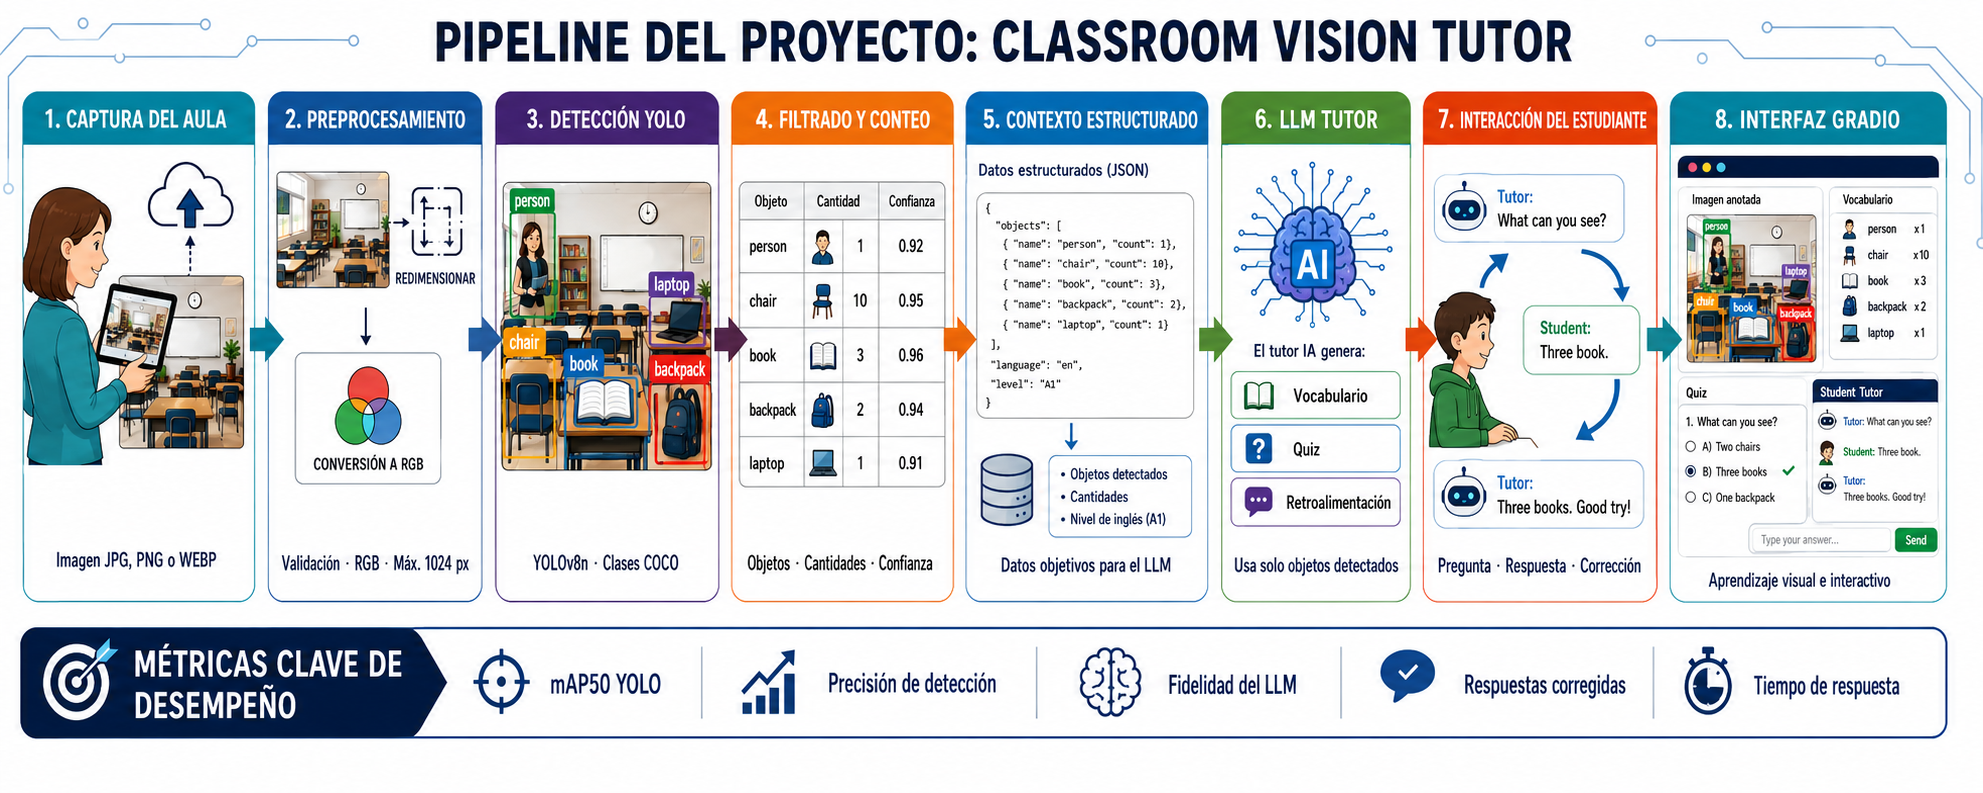